# 🚑 Riyadh Emergency Access - MVP

Ask a planning question in plain language. Two agents answer it, wired together with LangGraph:

```
START ──▶ graph_analyst ──▶ writer ──▶ END
          (calls graph tools)  (writes the report)
```

* **graph_analyst** runs graph algorithms on Riyadh's real road network (`critical_roads`, `suggest_new_sites`).
* **writer** turns the results into a short report for a city planner.


## 1. Setup

In [ ]:
!pip install -r requirements.txt

In [28]:
from dotenv import load_dotenv

load_dotenv()

True

In [50]:
import json
import os
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
from langchain_openai import ChatOpenAI

CENTER = (24.7136, 46.6753)
RADIUS_M = 10_000
DEFAULT_THRESHOLD_MIN = 10
CACHE_DIR = Path('cache')

MODEL_NAME = 'gemini-3-flash-preview'

api_key = os.environ['AI_API_KEY']

llm = ChatOpenAI(model=MODEL_NAME, base_url='https://generativelanguage.googleapis.com/v1beta/openai/', api_key=api_key, temperature=0)

## 2. Data: road network and hospitals
Roads become a directed graph (intersections = nodes, road segments = edges weighted by travel time in seconds).
Hospitals come from OpenStreetMap (`amenity=hospital`). The first run downloads for a few minutes; later runs use the cache.

In [40]:
import osmnx as ox


def load_data():
    CACHE_DIR.mkdir(exist_ok=True)
    graph_file = CACHE_DIR / f'roads_{RADIUS_M}.graphml'
    hosp_file = CACHE_DIR / f'hospitals_{RADIUS_M}.csv'
    if graph_file.exists() and hosp_file.exists():
        return ox.load_graphml(graph_file), pd.read_csv(hosp_file)

    G = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type='drive')
    G = ox.truncate.largest_component(G, strongly=True)
    G = ox.routing.add_edge_speeds(G)
    G = ox.routing.add_edge_travel_times(G)

    gdf = ox.features_from_point(CENTER, tags={'amenity': 'hospital'}, dist=RADIUS_M)
    pts = gdf.geometry.representative_point()
    names = gdf['name'] if 'name' in gdf.columns else pd.Series('Unnamed hospital', index=gdf.index)
    hospitals = pd.DataFrame({'name': names.fillna('Unnamed hospital').values,
                              'lat': pts.y.values, 'lon': pts.x.values})
    hospitals['node'] = ox.distance.nearest_nodes(G, X=hospitals.lon.values, Y=hospitals.lat.values)
    hospitals = hospitals.drop_duplicates('node').reset_index(drop=True)

    ox.save_graphml(G, graph_file)
    hospitals.to_csv(hosp_file, index=False)
    return G, hospitals


G, hospitals = load_data()
print(f'{len(G):,} road locations, {G.number_of_edges():,} road segments, {len(hospitals)} hospitals')

KeyboardInterrupt: 

In [10]:
def precompute_access(G, hospital_nodes):
    R = G.reverse(copy=True)
    R.add_node('SUPER')
    for h in hospital_nodes:
        R.add_edge('SUPER', h, travel_time=0.0)
    pred, dist = nx.dijkstra_predecessor_and_distance(R, 'SUPER', weight='travel_time')
    dist.pop('SUPER')
    next_hop = {v: p[0] for v, p in pred.items() if p and p[0] != 'SUPER'}
    return dist, next_hop


def road_name(G, u, v):
    data = min(G.get_edge_data(u, v).values(), key=lambda e: e.get('travel_time', 1e9))
    name = data.get('name')
    return ' / '.join(name) if isinstance(name, list) else name


def coverage_pct(dist, threshold_s):
    return round(100 * float((np.array(list(dist.values())) <= threshold_s).mean()), 1)


DIST, NEXT_HOP = precompute_access(G, hospitals['node'].tolist())
for m in (5, 10, 15):
    print(f'Within {m:>2} min of a hospital: {coverage_pct(DIST, m * 60)}%')

Within  5 min of a hospital: 89.7%
Within 10 min of a hospital: 99.6%
Within 15 min of a hospital: 100.0%


In [12]:
def critical_roads_impl(top_n=10):
    load = {v: 1 for v in DIST}
    road_load = {}
    for v in sorted(DIST, key=DIST.get, reverse=True):      # farthest first
        p = NEXT_HOP.get(v)
        if p is None:
            continue
        load[p] += load[v]
        name = road_name(G, v, p)
        if name and load[v] > road_load.get(name, (0,))[0]:
            road_load[name] = (load[v], v)
    ranked = sorted(road_load.items(), key=lambda kv: kv[1][0], reverse=True)[:top_n]
    return [{'road': name, 'share_of_area_pct': round(100 * n / len(DIST), 1),
             'lat': round(G.nodes[v]['y'], 5), 'lon': round(G.nodes[v]['x'], 5)}
            for name, (n, v) in ranked]


def suggest_sites_impl(k=3, threshold_minutes=DEFAULT_THRESHOLD_MIN, n_candidates=150):
    thr = threshold_minutes * 60
    uncovered = {v for v, t in DIST.items() if t > thr}
    result = {'threshold_minutes': threshold_minutes, 'coverage_before_pct': coverage_pct(DIST, thr), 'sites': []}
    if not uncovered:
        result['coverage_after_pct'] = result['coverage_before_pct']
        return result

    rng = np.random.default_rng(42)
    pool = list(uncovered)
    candidates = [pool[i] for i in rng.choice(len(pool), min(n_candidates, len(pool)), replace=False)]
    R = G.reverse(copy=False)
    reach = {c: set(nx.single_source_dijkstra_path_length(R, c, cutoff=thr, weight='travel_time'))
             for c in candidates}

    remaining = set(uncovered)
    for _ in range(k):
        best = max(candidates, key=lambda c: len(reach[c] & remaining))
        gained = reach[best] & remaining
        if not gained:
            break
        remaining -= gained
        candidates.remove(best)
        result['sites'].append({'lat': round(G.nodes[best]['y'], 5), 'lon': round(G.nodes[best]['x'], 5),
                                'newly_covered_pct': round(100 * len(gained) / len(DIST), 1)})
    result['coverage_after_pct'] = round(100 * (1 - len(remaining) / len(DIST)), 1)
    return result


print(json.dumps(critical_roads_impl(3), ensure_ascii=False, indent=2))
print(json.dumps(suggest_sites_impl(2, 5), indent=2))

[
  {
    "road": "الإنشراح",
    "share_of_area_pct": 4.5,
    "lat": 24.77943,
    "lon": 46.73882
  },
  {
    "road": "شارع خالد بن الوليد الفرعي",
    "share_of_area_pct": 4.5,
    "lat": 24.77904,
    "lon": 46.7379
  },
  {
    "road": "الظهيره",
    "share_of_area_pct": 4.3,
    "lat": 24.63258,
    "lon": 46.71152
  }
]
{
  "threshold_minutes": 5,
  "coverage_before_pct": 89.7,
  "sites": [
    {
      "lat": 24.63898,
      "lon": 46.58591,
      "newly_covered_pct": 1.8
    },
    {
      "lat": 24.7693,
      "lon": 46.76697,
      "newly_covered_pct": 1.6
    }
  ],
  "coverage_after_pct": 93.2
}


## 4. Tools
The docstring is what the model reads to decide when to call each tool.

In [46]:
from langchain_core.tools import tool


@tool
def critical_roads(top_n: int = 10) -> str:
    """Rank the roads that the most locations depend on to reach their nearest hospital.
    Returns JSON: road name, share of the area that depends on it (%), and a coordinate."""
    return json.dumps(critical_roads_impl(min(int(top_n), 25)), ensure_ascii=False)


@tool
def suggest_new_sites(k: int = 3, threshold_minutes: float = DEFAULT_THRESHOLD_MIN) -> str:
    """Recommend k sites for new emergency facilities that bring the most locations within
    `threshold_minutes` of driving. Returns coverage (%) before and after, and each site's coordinates."""
    return json.dumps(suggest_sites_impl(min(int(k), 10), float(threshold_minutes)))

## 5. Agents

In [51]:
from langchain.agents import create_agent

EMERGENCY_ACCESS_ANALYST_PROMPT = """You analyze emergency access to hospitals in Riyadh using your tools.
Call the tools the question needs, then report the results.
Copy every number exactly as the tool returned it. Never invent or round numbers."""

EMERGENCY_ACCESS_ANALYST_PROMPT = """You analyze emergency access to hospitals in Riyadh using your tools.
Call the tools the question needs, then report the results.
Copy every number exactly as the tool returned it. Never invent or round numbers."""

WRITER_PROMPT = """You write a short Markdown report for a non-technical city planner with the headings
Summary, Findings, Recommendations, Limitations.
Use only the numbers in the findings, copied exactly. Give coordinates for any recommended site.
Mention that drive times assume no traffic."""

planner = create_agent(model=llm, tools=[critical_roads, suggest_new_sites], system_prompt=EMERGENCY_ACCESS_ANALYST_PROMPT)

graph_analyst = create_agent(model=llm, tools=[critical_roads, suggest_new_sites], system_prompt=EMERGENCY_ACCESS_ANALYST_PROMPT)
writer = create_agent(model=llm, tools=[], system_prompt=WRITER_PROMPT)

## 6. LangGraph pipeline

In [52]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph


class State(TypedDict):
    query: str
    findings: str
    report: str

def planner_node(state: State) -> dict:
    result = graph_analyst.invoke({'messages': [('user', state['query'])]})
    return {'findings': result['messages'][-1].text}

def graph_analyst_node(state: State) -> dict:
    result = graph_analyst.invoke({'messages': [('user', state['query'])]})
    return {'findings': result['messages'][-1].text}


def writer_node(state: State) -> dict:
    prompt = f"QUESTION: {state['query']}\n\nFINDINGS:\n{state['findings']}"
    result = writer.invoke({'messages': [('user', prompt)]})
    return {'report': result['messages'][-1].text}


graph = StateGraph(State)
graph.add_node('graph_analyst', graph_analyst_node)
graph.add_node('writer', writer_node)
graph.add_edge(START, 'graph_analyst')
graph.add_edge('graph_analyst', 'writer')
graph.add_edge('writer', END)
pipeline = graph.compile()

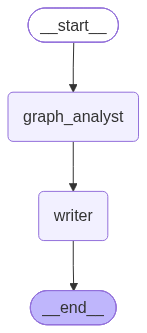

In [26]:
from IPython.display import Image, display

display(Image(pipeline.get_graph().draw_mermaid_png()))

## 7. Run it

In [53]:
from IPython.display import Markdown, display


def ask(question: str) -> str:
    result = pipeline.invoke({'query': question, 'findings': '', 'report': ''})
    display(Markdown(result['report']))
    return result['report']


ask('Where should Riyadh add 3 new emergency centers so more of the city is within 10 minutes of a hospital, '
    'and which 5 roads matter most for reaching hospitals?')

OpenAIInvalidRequestError: Error code: 400 - [{'error': {'code': 400, 'message': 'Function call is missing a thought_signature in functionCall parts. This is required for tools to work correctly, and missing thought_signature may lead to degraded model performance. Additional data, function call `default_api:suggest_new_sites` , position 2. Please refer to https://ai.google.dev/gemini-api/docs/thought-signatures for more details.', 'status': 'INVALID_ARGUMENT'}}]

## 8. Map
🔴 hospitals · 🟠 critical roads · 🟢 suggested sites

In [ ]:
import folium

m = folium.Map(location=CENTER, zoom_start=12)
for _, h in hospitals.iterrows():
    folium.CircleMarker([h.lat, h.lon], radius=5, color='red', fill=True, tooltip=h['name']).add_to(m)
for r in critical_roads_impl(5):
    folium.Marker([r['lat'], r['lon']], icon=folium.Icon(color='orange'), tooltip=r['road']).add_to(m)
for s in suggest_sites_impl(3)['sites']:
    folium.Marker([s['lat'], s['lon']], icon=folium.Icon(color='green'), tooltip='Suggested site').add_to(m)
m